#### Metodos Numericos  2026 A
#### Pinto Andrango Juan Francisco
#### Actividad extracurricular 3b
#### Módulo Logging
#### 20/07/2026 

### Link del Repositorio De Git Hub

### Objetivo 

Conocer y utilizar el módulo de logging en Python. 

### Indicaciones

Investigue sobre el módulo de logging.

Cree un ejemplo que: realice logging en consola, en un archivo, en un mensaje de Telegram. 

Modifique el logging para mostrar el nombre del archivo, incluir la fecha y la hora, cambiar de color, etc

### Modulo de Logging 

El modulo login se usa para una grabar todo lo que pasa. el loggin guara el historial de los archivos para poder hacer una revision dias mas tarde o meses despues. hace un filtrado de gravedad permite separa informacion. puede notificar y enviar notificaciones, grabaciones a diferentes lugares al mismo tiempo como un archivo de texto  a la pantalla y a un celular 

In [10]:
import requests

TOKEN = "8972869757:AAHGWEUleQf7MS6UazXj5C9sdrAPQMTS5gA"

url = f"https://api.telegram.org/bot{TOKEN}/getUpdates"

respuesta = requests.get(url)

print(respuesta.text)

{"ok":true,"result":[]}


In [12]:
import requests

TOKEN = "8972869757:AAHGWEUleQf7MS6UazXj5C9sdrAPQMTS5gA"

url = f"https://api.telegram.org/bot{TOKEN}/getUpdates"

r = requests.get(url)

print(r.status_code)
print(r.text)

200
{"ok":true,"result":[{"update_id":337755543,
"message":{"message_id":1,"from":{"id":1494604192,"is_bot":false,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","language_code":"es"},"chat":{"id":1494604192,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","type":"private"},"date":1784592957,"text":"/start","entities":[{"offset":0,"length":6,"type":"bot_command"}]}},{"update_id":337755544,
"message":{"message_id":2,"from":{"id":1494604192,"is_bot":false,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","language_code":"es"},"chat":{"id":1494604192,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","type":"private"},"date":1784592972,"text":"/start","entities":[{"offset":0,"length":6,"type":"bot_command"}]}},{"update_id":337755545,
"message":{"message_id":3,"from":{"id":1494604192,"is_bot":false,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","language_code":"es"},"chat":{"id":1494604192,"first

In [13]:
import requests

TOKEN = "8972869757:AAHGWEUleQf7MS6UazXj5C9sdrAPQMTS5gA"
CHAT_ID = "1494604192"

url = f"https://api.telegram.org/bot{TOKEN}/sendMessage"

datos = {
    "chat_id": CHAT_ID,
    "text": "Hola desde Python"
}

r = requests.post(url, data=datos)

print(r.status_code)
print(r.text)

200
{"ok":true,"result":{"message_id":10,"from":{"id":8972869757,"is_bot":true,"first_name":"Myreal","username":"Jfran16_bot"},"chat":{"id":1494604192,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","type":"private"},"date":1784593088,"text":"Hola desde Python"}}


In [14]:
print(r.status_code)
print(r.text)

200
{"ok":true,"result":{"message_id":10,"from":{"id":8972869757,"is_bot":true,"first_name":"Myreal","username":"Jfran16_bot"},"chat":{"id":1494604192,"first_name":"Juanfran","last_name":"Pinto","username":"Juan16fran","type":"private"},"date":1784593088,"text":"Hola desde Python"}}


In [18]:
import logging
import requests
import sys
from colorlog import ColoredFormatter

class TelegramHandler(logging.Handler):
    def __init__(self, token, chat_id):
        super().__init__()
        self.token = token
        self.chat_id = chat_id

    def emit(self, record):
        log_entry = self.format(record)
        url = f"https://api.telegram.org/bot{self.token}/sendMessage"
        payload = {
            'chat_id': self.chat_id,
            'text': log_entry,
            'parse_mode': 'HTML'
        }
        try:
            requests.post(url, data=payload, timeout=5)
        except Exception:
            self.handleError(record)

def setup_logger():
    ### esto es mi id de telegram y el token de mi bot ###
    TOKEN = "8972869757:AAHGWEUleQf7MS6UazXj5C9sdrAPQMTS5gA"
    CHAT_ID = "1494604192"

    logger = logging.getLogger("MiLoggerDeber")
    
    if logger.hasHandlers():
        logger.handlers.clear()
        
    logger.setLevel(logging.DEBUG)

    console_formatter = ColoredFormatter(
        "%(log_color)s%(asctime)s | %(filename)s:%(lineno)d | %(levelname)-8s | %(message)s",
        datefmt='%Y-%m-%d %H:%M:%S',
        reset=True,
        log_colors={
            'DEBUG':    'cyan',
            'INFO':     'green',
            'WARNING':  'yellow',
            'ERROR':    'red',
            'CRITICAL': 'red,bg_white',
        }
    )

    file_formatter = logging.Formatter(
        "%(asctime)s | %(filename)s:%(lineno)d | %(levelname)s | %(message)s",
        datefmt='%Y-%m-%d %H:%M:%S'
    )

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(console_formatter)
    console_handler.setLevel(logging.DEBUG)

    file_handler = logging.FileHandler("registro_actividad.log")
    file_handler.setFormatter(file_formatter)
    file_handler.setLevel(logging.INFO)

    telegram_handler = TelegramHandler(TOKEN, CHAT_ID)
    telegram_handler.setFormatter(file_formatter)
    telegram_handler.setLevel(logging.ERROR)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
    logger.addHandler(telegram_handler)

    return logger

log = setup_logger()

log.debug("Este mensaje solo va a la consola")
log.info("Este mensaje va a consola y archivo")
log.warning("Advertencia: Revisar configuracion")
log.error("Error critico: Enviando alerta a Telegram")
log.critical("Falla catastrofica del sistema")

2026-07-20 19:20:39 | 2975273851.py:75 | DEBUG    | Este mensaje solo va a la consola
2026-07-20 19:20:39 | 2975273851.py:76 | INFO     | Este mensaje va a consola y archivo
2026-07-20 19:20:39 | 2975273851.py:77 | WARNING  | Advertencia: Revisar configuracion
2026-07-20 19:20:39 | 2975273851.py:78 | ERROR    | Error critico: Enviando alerta a Telegram
2026-07-20 19:20:40 | 2975273851.py:79 | CRITICAL | Falla catastrofica del sistema


#### Evidencia de Correcta Ejecucion 

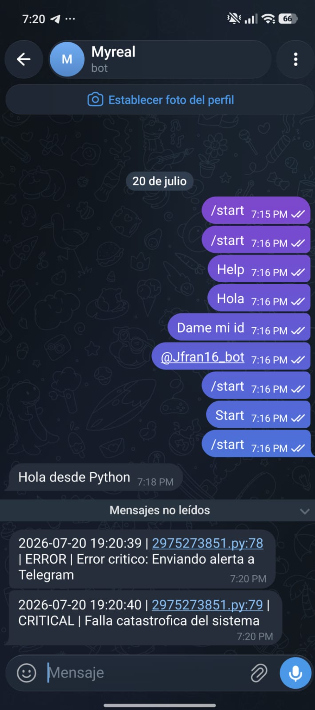